In [2]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np
import torch

/Users/i588313/Library/Python/3.11/lib/python/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.24.3 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [2]:
# Define the quantum device
n_qubits = 4  # Adjust based on simulation speed (4-8 is usually fast)
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_projection_circuit(inputs, weights):
    # 1. Data Encoding: Map classical features to quantum state
    # We assume inputs are pre-processed to match n_qubits
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # 2. Variational Layers: Trainable quantum gates
    # weights shape: (n_layers, n_qubits, 3) for StronglyEntangling
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    # 3. Measurement: Return expectation values for each qubit
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [3]:
n_qubits = 6  # Adjust based on simulation speed (4-8 is usually fast)
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_projection_circuit(inputs, weights):
    inputs=torch.from_numpy(inputs)
    # 1. State Preparation / Data Encoding
    # H -> Ry(arctan(x)) -> Rz(arctan(x^2))
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        # Use accessing column i for all batches: inputs[..., i]
        # This handles both batched inputs (batch, n_qubits) and single inputs (n_qubits)
        feature = inputs[..., i]
        qml.RY(torch.arctan(feature), wires=i)
        qml.RZ(torch.arctan(feature**2), wires=i)
    
    # 2. Variational Layer (Entanglement + Rotation)
    # Get number of layers from weights shape
    n_layers = weights.shape[0] if len(weights.shape) > 2 else 1
    
    for l in range(n_layers):
        # CNOT chain: 0->1, 1->2, ..., (n-1)->0
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
            
        # Rotations: R(alpha, beta, gamma)
        # weights shape: (n_layers, n_qubits, 3)
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
    
    # 3. Measurement
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [3]:
n_qubits = 6  # Adjust based on simulation speed (4-8 is usually fast)
dev = qml.device("default.qubit", wires=n_qubits)

DEPOLARIZING_PROB = 0.01
AMPLITUDE_DAMPING_GAMMA = 0.005

@qml.qnode(dev)
def quantum_projection_circuit(inputs, weights):
    inputs=torch.from_numpy(inputs)
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        feature = inputs[..., i]
        qml.RY(torch.arctan(feature), wires=i)
        qml.RZ(torch.arctan(feature**2), wires=i)
        qml.DepolarizingChannel(DEPOLARIZING_PROB, wires=i)
        qml.AmplitudeDamping(AMPLITUDE_DAMPING_GAMMA, wires=i)
    
    n_layers = weights.shape[0] if len(weights.shape) > 2 else 1
    
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
            qml.DepolarizingChannel(DEPOLARIZING_PROB * 2, wires=i)
            qml.DepolarizingChannel(DEPOLARIZING_PROB * 2, wires=(i + 1) % n_qubits)
            
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
            qml.DepolarizingChannel(DEPOLARIZING_PROB, wires=i)
            qml.AmplitudeDamping(AMPLITUDE_DAMPING_GAMMA, wires=i)
    
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

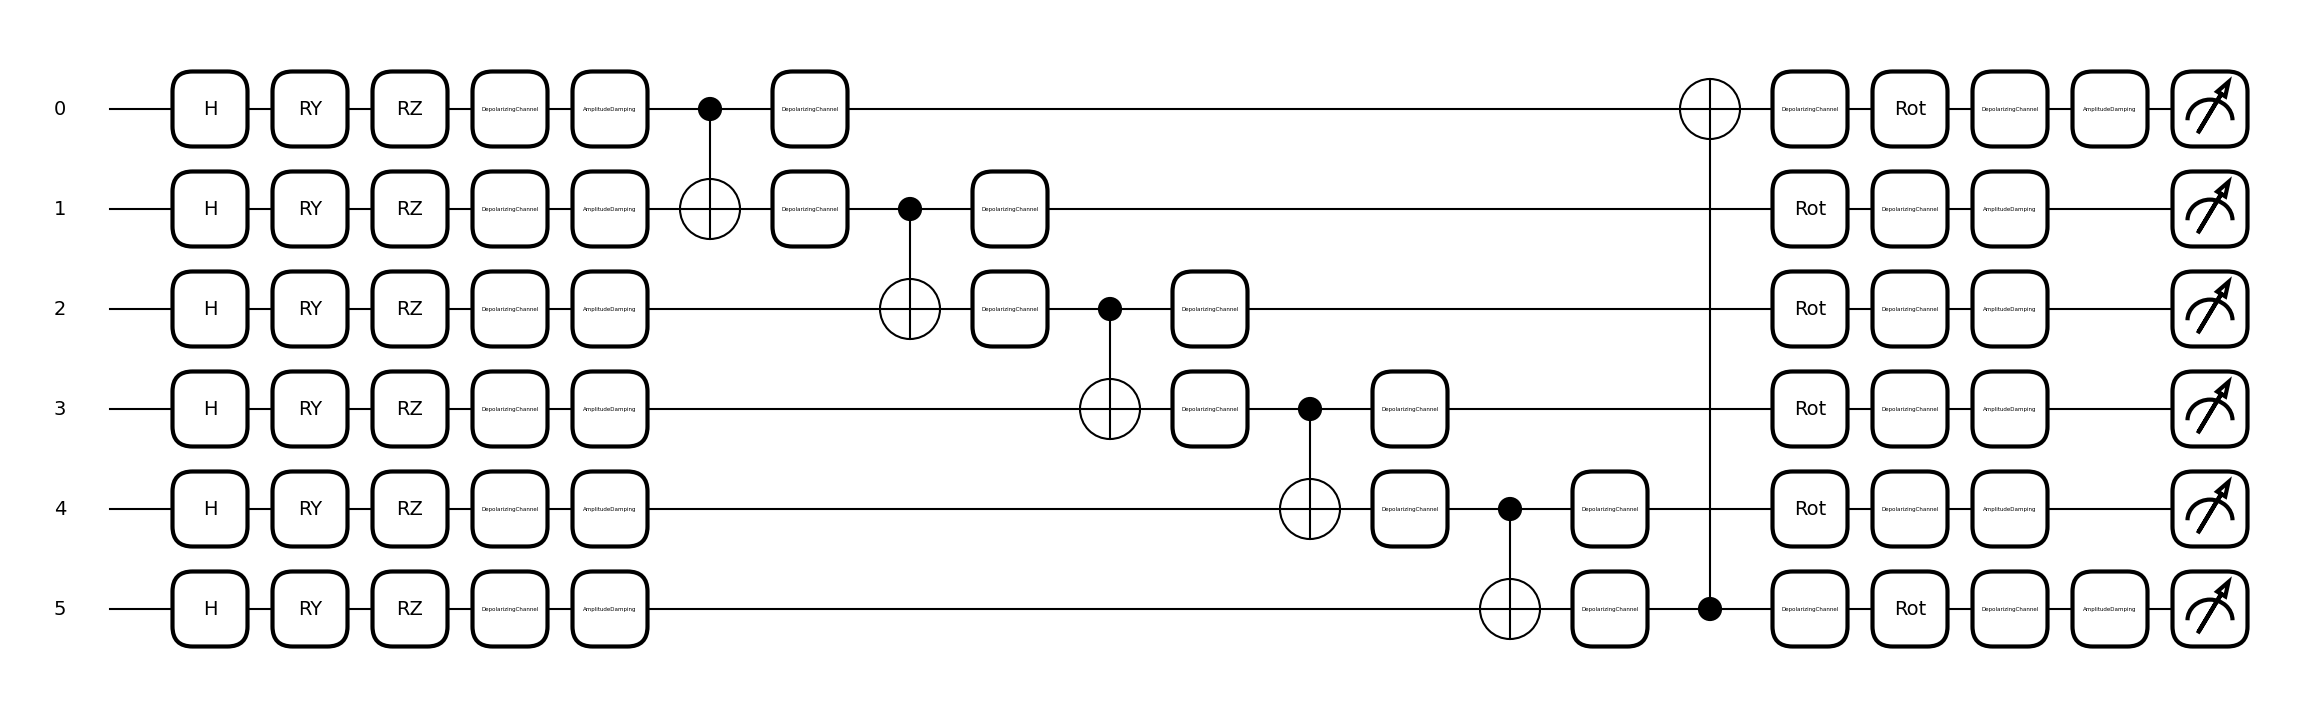

In [4]:
n_layers=1
fig, ax = qml.draw_mpl(quantum_projection_circuit)(np.random.random(n_qubits),np.random.random((n_layers,n_qubits,3)))
plt.show()